# CBSA MAUP

Side-by-side comparison of tract and block-group graphs for a single CBSA.

1. **`plot_degree_distribution_maup(cbsa_code)`** — degree-distribution histograms for tracts and block groups separately.
2. **`plot_graph_maup(cbsa_code, var, overlay_shapefile)`** — one PNG per decade, tract and block-group graphs side by side, coloured with a **shared** normalisation when `var` is set.
3. **`plot_score_graph_maup(cbsa_code, metrics)`** — metric time series for both levels on shared axes (tracts solid, block groups dashed).

In [2]:
import json
import glob
import os
import re as _re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd

YEARS   = [1980, 1990, 2000, 2010, 2020]
CBSA_DIR = '../study_areas'
VINTAGE  = None       # None = all vintages; set e.g. 'march_2020' to restrict
OUT_DIR  = None       # set automatically in the CBSA cell below

SCORE_CSV_DIR_TRACTS = '../outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage'
SCORE_CSV_DIR_BG     = '../outputs/block_groups_in_cbsa_2020-2010-2000-1990_years_march_2020_vintage'

_cbsa_df  = pd.read_csv('cbsa-name dictionary.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [3]:
def find_files(cbsa_code, census_geography_type, vintage=VINTAGE):
    """
    Return {year: filepath} for every decade that has a connected JSON for
    this CBSA and geography type.
    """
    found = {}
    for yr in YEARS:
        pattern = os.path.join(
            CBSA_DIR, str(yr),
            f'{census_geography_type}_in_cbsa_{cbsa_code}_{yr}_*_vintage_connected.json'
        )
        matches = sorted(glob.glob(pattern))
        if vintage:
            matches = [m for m in matches if vintage in os.path.basename(m)]
        if matches:
            found[yr] = matches[0]
    return found


def load_graph(filepath):
    """Load a connected JSON and return (nodes_dict, nx.Graph)."""
    with open(filepath) as f:
        d = json.load(f)
    nodes_list = d['nodes']
    nodes = {node['id']: node for node in nodes_list}
    G = nx.Graph()
    for node_id, attrs in nodes.items():
        G.add_node(node_id, **attrs)
    for i, neighbours in enumerate(d['adjacency']):
        src_id = nodes_list[i]['id']
        for nb in neighbours:
            j = nb['id']
            if src_id < j:
                G.add_edge(src_id, j, shared_perim=nb.get('shared_perim', 1))
    return nodes, G

In [4]:
def _node_positions(G):
    pos, missing = {}, []
    for node_id, attrs in G.nodes(data=True):
        cx = attrs.get('centroid_x')
        cy = attrs.get('centroid_y')
        if cx is not None and cy is not None:
            pos[node_id] = (cx, cy)
        else:
            missing.append(node_id)
    if not pos:
        print('  centroid_x/centroid_y not found — falling back to spring layout')
        return nx.spring_layout(G, seed=42)
    if missing:
        mean_x = sum(x for x, y in pos.values()) / len(pos)
        mean_y = sum(y for x, y in pos.values()) / len(pos)
        for node_id in missing:
            pos[node_id] = (mean_x, mean_y)
    return pos


def _compute_var(G, var):
    raw = []
    for i in G.nodes():
        attrs = G.nodes[i]
        if var == 'Black_Share':
            denom = (attrs.get('BLACK') or 0) + (attrs.get('WHITE') or 0)
            val = (attrs.get('BLACK') or 0) / denom if denom > 0 else np.nan
        elif var == 'Poc_Share':
            totpop = attrs.get('TOTPOP') or 0
            val = (attrs.get('POC') or 0) / totpop if totpop > 0 else np.nan
        else:
            val = attrs.get(var, 0) or 0
        raw.append(val)
    return np.array(raw, dtype=float)

In [5]:
def plot_degree_distribution_maup(cbsa_code, vintage=VINTAGE, out_dir=None):
    """
    Produce degree-distribution histograms for tracts and block groups separately.
    Outputs one 3-row figure + text report per geography level.
    """
    if out_dir is None:
        out_dir = OUT_DIR
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    os.makedirs(out_dir, exist_ok=True)

    for geo_type in ['tracts', 'block_groups']:
        files = find_files(cbsa_code, geo_type, vintage=vintage)
        if not files:
            print(f'No {geo_type} files found for CBSA {cbsa_code}')
            continue

        years = sorted(files)
        graphs_by_year, nodes_by_year, degrees_by_year = {}, {}, {}
        for yr in years:
            n, G = load_graph(files[yr])
            graphs_by_year[yr] = G
            nodes_by_year[yr]  = n
            degrees_by_year[yr] = dict(G.degree())

        all_degs  = [d for yr in years for d in degrees_by_year[yr].values()]
        q1, q3   = np.percentile(all_degs, [25, 75])
        threshold = q3 + 1.5 * (q3 - q1)
        max_deg   = max(all_degs)

        geo_label = geo_type.replace('_', ' ')
        fig, axes = plt.subplots(3, len(years), figsize=(4 * len(years), 10.5), squeeze=False)
        fig.suptitle(f'Degree Distribution — {cbsa_name} ({geo_label})',
                     fontsize=14, fontweight='bold', y=1.02)

        row_labels = [
            f'All  (threshold={threshold:.1f})',
            f'Degree \u2264 {threshold:.1f}',
            f'Degree \u2265 {threshold:.1f}',
        ]

        for col, yr in enumerate(years):
            vals_all   = list(degrees_by_year[yr].values())
            vals_below = [d for d in vals_all if d <= threshold]
            vals_above = [d for d in vals_all if d >= threshold]

            for row, vals in enumerate([vals_all, vals_below, vals_above]):
                ax = axes[row][col]
                if row == 0:
                    bins = range(0, max_deg + 2)
                elif row == 1:
                    bins = range(0, int(threshold) + 2)
                else:
                    bins = range(int(threshold), (max(vals) if vals else int(threshold)) + 2)
                if vals:
                    ax.hist(vals, bins=bins, color='steelblue', edgecolor='white',
                            linewidth=0.4, alpha=0.85)
                if col == 0:
                    ax.set_ylabel(row_labels[row], fontsize=9)
                else:
                    ax.set_yticklabels([])
                if row == 0:
                    ax.set_title(str(yr), fontsize=12, fontweight='bold')
                ax.set_xlabel('Degree', fontsize=9)
                ax.tick_params(labelsize=8)
                ax.text(0.97, 0.95, f'n={len(vals):,}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=8, color='#555')
                if vals:
                    ax.text(0.97, 0.85, f'med={np.median(vals):.1f}', transform=ax.transAxes,
                            ha='right', va='top', fontsize=8, color='#555')

        plt.tight_layout()
        fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{geo_type}_degree_dist.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'Saved {fig_path}')
        plt.show()

        # Text report: top-20 highest-degree units per year
        text_lines = [f'{cbsa_name} ({geo_label}) \u2014 Degree Report', '=' * 60]
        for yr in years:
            degrees = degrees_by_year[yr]
            nodes   = nodes_by_year[yr]
            text_lines += ['', f'{yr}  |  {os.path.basename(files[yr])}']
            top20 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:20]
            text_lines.append(f'  {"Rank":>4}  {"Degree":>6}  Unit')
            text_lines.append(f'  {"-" * 55}')
            for rank, (node_id, deg) in enumerate(top20, 1):
                attrs = nodes.get(node_id, {})
                label = attrs.get('NAME') or attrs.get('GEOID') or attrs.get('GISJOIN', str(node_id))
                text_lines.append(f'  {rank:>4}  {deg:>6}  {label}')

        txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{geo_type}_degree_report.txt')
        with open(txt_path, 'w') as f:
            f.write('\n'.join(text_lines) + '\n')
        print(f'Saved {txt_path}')

        print(f'\nDegree statistics \u2014 {cbsa_name} ({geo_label})  (threshold = {threshold:.1f})')
        print(f"{' Year':>6}  {'Leaves':>7}  {'Mean':>8}  {'Median':>8}  {'Min':>5}  {'Max':>5}  {'Std':>8}")
        print('-' * 60)
        for yr in years:
            arr = np.array(list(degrees_by_year[yr].values()))
            print(f"{yr:>6}  {int((arr == 1).sum()):>7}  {arr.mean():>8.2f}  "
                  f"{np.median(arr):>8.2f}  {int(arr.min()):>5}  {int(arr.max()):>5}  {arr.std():>8.2f}")

In [6]:
def _metric_label(col):
    """Return a human-readable label for a metric column name."""
    def _lam(s):
        return '\u221e' if s == 'lim' else s

    _moran_map = {
        'A':   'Adjacency',
        'P':   'Row Standardized Adjacency',
        'M':   'Metropolis',
        'L':   'Laplacian',
        'D_1': 'Inverse Distance',
        'D_2': 'Inverse Distance 2',
    }

    if col == 'e_assort':
        return 'Assortativity-Edge Count'
    if col == 'he_assort':
        return 'Assortativity-Halfedge Count'

    m = _re.fullmatch(r'dissimilarity_(\d+)', col)
    if m:
        p = m.group(1)
        return 'Dissimilarity' if p == '1' else f'Dissimilarity (P = {p})'

    m = _re.fullmatch(r'moran_(.+)', col)
    if m:
        key = m.group(1)
        return f"Moran's I ({_moran_map.get(key, key)})"

    m = _re.fullmatch(r'half_edge_exact_(.+)', col)
    if m:
        return f'Half Edge Exact (\u03bb={_lam(m.group(1))})'

    m = _re.fullmatch(r'half_edge_(.+)', col)
    if m:
        return f'Half Edge (\u03bb={_lam(m.group(1))})'

    m = _re.fullmatch(r'edge_exact_(.+)', col)
    if m:
        return f'Edge Exact (\u03bb={_lam(m.group(1))})'

    m = _re.fullmatch(r'edge_(.+)', col)
    if m:
        return f'Edge (\u03bb={_lam(m.group(1))})'

    m = _re.fullmatch(r"skew'_(self|other)_exact_(.+)", col)
    if m:
        return f"Skew' ({m.group(1).title()} Exact, \u03bb={_lam(m.group(2))})"

    m = _re.fullmatch(r"skew'_(self|other)_(.+)", col)
    if m:
        return f"Skew' ({m.group(1).title()}, \u03bb={_lam(m.group(2))})"

    m = _re.fullmatch(r'skew_(self|other)_exact_(.+)', col)
    if m:
        return f'Skew ({m.group(1).title()} Exact, \u03bb={_lam(m.group(2))})'

    m = _re.fullmatch(r'skew_(self|other)_(.+)', col)
    if m:
        return f'Skew ({m.group(1).title()}, \u03bb={_lam(m.group(2))})'

    return col

In [7]:
def plot_graph_maup(cbsa_code, overlay_shapefile=False, var=None, vintage=VINTAGE, out_dir=None,
                    normalize='global', threshold='maj'):
    """
    normalize : 'global' — one shared colormap scale across all years and both geo levels (default)
                'local'  — each subplot uses its own min/max normalization
    threshold : 'maj' — cutoff = 0.5; 'avg' — cutoff = per-year/level mean share
                Applies when var is 'black_share_above_threshold' or
                'poc_share_above_threshold', which colour each node by how far its
                share exceeds the threshold (nodes below threshold shown in grey).
    """
    _ABOVE_THRESH_BASES = {
        'black_share_above_threshold': 'Black_Share',
        'poc_share_above_threshold':   'Poc_Share',
    }
    is_above_thresh = var in _ABOVE_THRESH_BASES

    def _excess_arr(G):
        base   = _compute_var(G, _ABOVE_THRESH_BASES[var])
        cutoff = 0.5 if threshold == 'maj' else float(np.nanmean(base[~np.isnan(base)]))
        return np.where(~np.isnan(base) & (base >= cutoff), base - cutoff, np.nan)

    if out_dir is None:
        out_dir = OUT_DIR

    tract_files = find_files(cbsa_code, 'tracts',       vintage=vintage)
    bg_files    = find_files(cbsa_code, 'block_groups',  vintage=vintage)

    all_years = sorted(set(list(tract_files.keys()) + list(bg_files.keys())))
    if not all_years:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    if is_above_thresh:
        thresh_label = '50%' if threshold == 'maj' else 'mean'
        base_name    = 'Black' if _ABOVE_THRESH_BASES[var] == 'Black_Share' else 'POC'
        var_disp     = f'{base_name} Share Excess (≥ {thresh_label})'
        cmap         = plt.cm.plasma.copy()
        cmap.set_bad(color='lightgray', alpha=0.6)
    else:
        var_disp = var
        cmap     = plt.cm.plasma

    # Global normalization: pre-compute min/max across all years and both levels
    global_min, global_max = None, None
    if var is not None and normalize == 'global':
        all_vals = []
        for files in (tract_files, bg_files):
            for fp in files.values():
                _, G = load_graph(fp)
                arr   = _excess_arr(G) if is_above_thresh else _compute_var(G, var)
                valid = arr[~np.isnan(arr)]
                if len(valid):
                    all_vals.extend(valid.tolist())
        if all_vals:
            global_min = 0.0 if is_above_thresh else min(all_vals)
            global_max = max(all_vals)

    # Accumulators for report
    report = {
        'tracts':       {'graph': {}, 'black_share': {}, 'poc_share': {}, 'var': {}},
        'block_groups': {'graph': {}, 'black_share': {}, 'poc_share': {}, 'var': {}},
    }

    for yr in all_years:
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        fig.suptitle(f'{cbsa_name} — {yr}', fontsize=15, fontweight='bold')

        levels = [
            ('Tracts',       tract_files, axes[0], 'tracts'),
            ('Block Groups', bg_files,    axes[1], 'block_groups'),
        ]

        nc_ref = None
        for level_label, files, ax, geo_key in levels:
            if yr not in files:
                ax.text(0.5, 0.5, f'No {level_label} data\nfor {yr}',
                        ha='center', va='center', transform=ax.transAxes, fontsize=12)
                ax.set_axis_off()
                ax.set_title(level_label, fontsize=12)
                continue

            _, G = load_graph(files[yr])
            pos  = _node_positions(G)

            report[geo_key]['graph'][yr]      = (G.number_of_nodes(), G.number_of_edges())
            report[geo_key]['black_share'][yr] = _compute_var(G, 'Black_Share')
            report[geo_key]['poc_share'][yr]   = _compute_var(G, 'Poc_Share')

            ax.set_title(
                f'{level_label}  ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)',
                fontsize=11, fontweight='bold',
            )

            if overlay_shapefile:
                shp_path = files[yr].replace('_connected.json', '.shp')
                if os.path.exists(shp_path):
                    gdf = gpd.read_file(shp_path).to_crs('esri:102003')
                    gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#aaaaaa', linewidth=0.5)
                else:
                    print(f'  Shapefile not found: {shp_path}')

            nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.6, edge_color='#888')
            node_sizes = [2] * G.number_of_nodes()

            if var is not None:
                arr = _excess_arr(G) if is_above_thresh else _compute_var(G, var)
                report[geo_key]['var'][yr] = arr

                if normalize == 'global':
                    vmin, vmax = global_min, global_max
                else:
                    vmin = 0.0 if is_above_thresh else float(np.nanmin(arr))
                    vmax = float(np.nanmax(arr)) if not np.all(np.isnan(arr)) else 1.0

                nc = nx.draw_networkx_nodes(
                    G, pos, ax=ax,
                    node_color=arr, cmap=cmap,
                    vmin=vmin, vmax=vmax,
                    node_size=node_sizes, alpha=0.85,
                )
                if normalize == 'local':
                    fig.colorbar(nc, ax=ax, label=f'{var_disp}  ({vmin:.3f}–{vmax:.3f})',
                                 shrink=0.5, pad=0.02, location='bottom')
                else:
                    nc_ref = nc
            else:
                nx.draw_networkx_nodes(G, pos, ax=ax,
                                       node_color='steelblue',
                                       node_size=node_sizes, alpha=0.85)
            ax.set_axis_off()

        if var is not None and normalize == 'global' and nc_ref is not None:
            cbar = fig.colorbar(
                nc_ref, ax=list(axes),
                location='bottom', shrink=0.25, aspect=40, pad=0.02,
            )
            cbar.set_label(
                f'{var_disp}  (shared scale: {global_min:.3f} – {global_max:.3f})',
                fontsize=9,
            )

        plt.tight_layout()
        mode    = 'overlay' if overlay_shapefile else 'graph'
        var_tag = f'_{var}' if var is not None else ''
        fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{yr}{var_tag}_maup_{mode}.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'Saved {fig_path}')
        plt.show()

    # Report
    def _stat_row(arr):
        return (f"{np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>10.4f}  "
                f"{np.nanmin(arr):>10.4f}  {np.nanmax(arr):>10.4f}  {np.nanstd(arr):>10.4f}")

    stat_header = f"{'Year':>6}  {'Mean':>10}  {'Median':>10}  {'Min':>10}  {'Max':>10}  {'Std':>10}"
    stat_sep    = '-' * 63

    text_lines = [f'Graph report — {cbsa_name}', '=' * 70]

    for geo_key, geo_label in (('tracts', 'Tracts'), ('block_groups', 'Block Groups')):
        s = report[geo_key]
        if not s['graph']:
            continue
        text_lines += ['', f'── {geo_label} ──']

        text_lines += ['', 'Graph Structure', f"{'Year':>6}  {'Nodes':>6}  {'Edges':>6}", '-' * 22]
        for yr, (n, e) in sorted(s['graph'].items()):
            text_lines.append(f"{yr:>6}  {n:>6}  {e:>6}")

        text_lines += ['', 'Black Share  (BLACK / (BLACK + WHITE))', stat_header, stat_sep]
        for yr, arr in sorted(s['black_share'].items()):
            text_lines.append(f"{yr:>6}  {_stat_row(arr)}")

        text_lines += ['', 'POC Share  (POC / TOTPOP)', stat_header, stat_sep]
        for yr, arr in sorted(s['poc_share'].items()):
            text_lines.append(f"{yr:>6}  {_stat_row(arr)}")

        if var is not None and s['var']:
            text_lines += ['', var_disp, stat_header, stat_sep]
            for yr, arr in sorted(s['var'].items()):
                text_lines.append(f"{yr:>6}  {_stat_row(arr)}")

    print('\n'.join(text_lines))
    var_tag = f'_{var}' if var is not None else ''
    txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}{var_tag}_maup_graph_report.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(text_lines) + '\n')
    print(f'Saved {txt_path}')

In [8]:
def plot_graph_stats_maup(cbsa_code, vintage=VINTAGE, out_dir=None):
    if out_dir is None:
        out_dir = OUT_DIR

    tract_files = find_files(cbsa_code, 'tracts',      vintage=vintage)
    bg_files    = find_files(cbsa_code, 'block_groups', vintage=vintage)

    if not tract_files and not bg_files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    level_cfgs = [
        ('Tracts',       tract_files, 'steelblue', '-'),
        ('Block Groups', bg_files,    'coral',     ':'),
    ]

    stats = {
        label: {
            'years': [], 'poc_mean': [], 'black_mean': [],
            'nodes': [], 'edges': [], 'max_deg': [], 'leaves': [],
        }
        for label, _, _, _ in level_cfgs
    }

    # Global shares are CBSA-wide population totals — identical regardless of areal unit.
    # Compute once per year, preferring tracts then falling back to block groups.
    all_yrs = sorted(set(list(tract_files.keys()) + list(bg_files.keys())))
    global_years, global_poc, global_black = [], [], []
    for yr in all_yrs:
        fp = tract_files.get(yr) or bg_files.get(yr)
        _, G = load_graph(fp)
        sum_totpop = sum((G.nodes[n].get('TOTPOP') or 0) for n in G.nodes())
        sum_poc    = sum((G.nodes[n].get('POC')    or 0) for n in G.nodes())
        sum_black  = sum((G.nodes[n].get('BLACK')  or 0) for n in G.nodes())
        sum_white  = sum((G.nodes[n].get('WHITE')  or 0) for n in G.nodes())
        global_years.append(yr)
        global_poc.append(sum_poc / sum_totpop if sum_totpop > 0 else np.nan)
        global_black.append(sum_black / (sum_black + sum_white) if (sum_black + sum_white) > 0 else np.nan)

    for label, files, color, ls in level_cfgs:
        for yr in sorted(files):
            _, G = load_graph(files[yr])
            degrees   = [d for _, d in G.degree()]
            poc_arr   = _compute_var(G, 'Poc_Share')
            black_arr = _compute_var(G, 'Black_Share')

            s = stats[label]
            s['years'].append(yr)
            s['poc_mean'].append(float(np.nanmean(poc_arr)))
            s['black_mean'].append(float(np.nanmean(black_arr)))
            s['nodes'].append(G.number_of_nodes())
            s['edges'].append(G.number_of_edges())
            s['max_deg'].append(max(degrees) if degrees else 0)
            s['leaves'].append(sum(1 for d in degrees if d == 1))

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(
        f'{cbsa_name} — Graph Statistics Over Time  (Tracts vs Block Groups)',
        fontsize=14, fontweight='bold',
    )

    # Global share panels: single line (CBSA-wide, areal-unit-invariant)
    for ax, gvals, title in [
        (axes[0, 0], global_poc,   'Global POC Share'),
        (axes[0, 2], global_black, 'Global Black Share'),
    ]:
        ax.plot(global_years, gvals, marker='o', linewidth=1.8, color='steelblue')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel('Share', fontsize=9)
        ax.set_xticks(all_yrs)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)

    # Mean share and structural metric panels: one line per level
    for ax, metric, title, ylabel in [
        (axes[0, 1], 'poc_mean',   'Mean POC Share',     'Share'),
        (axes[0, 3], 'black_mean', 'Mean Black Share',   'Share'),
        (axes[1, 0], 'nodes',      'Number of Nodes',    'Count'),
        (axes[1, 1], 'edges',      'Number of Edges',    'Count'),
        (axes[1, 2], 'max_deg',    'Max Degree',         'Degree'),
        (axes[1, 3], 'leaves',     'Number of Leaves',   'Count'),
    ]:
        for label, files, color, ls in level_cfgs:
            s = stats[label]
            if not s['years']:
                continue
            ax.plot(s['years'], s[metric], marker='o', linewidth=1.8,
                    color=color, linestyle=ls, label=label)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticks(all_yrs)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, framealpha=0.7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_maup_graph_stats.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved {fig_path}')
    plt.show()

In [9]:
def plot_threshold_components_maup(cbsa_code, comparison='black', threshold='maj',
                                    vintage=VINTAGE, out_dir=None):
    """
    For each decade, take the induced subgraph of nodes whose share is strictly
    above the threshold (positive excess) and count its connected components.
    Plots component count and above-threshold node count over time for tracts
    and block groups.

    Parameters
    ----------
    comparison : 'black' or 'poc'
    threshold  : 'maj' — cutoff = 0.5; 'avg' — cutoff = per-year/level mean share
    """
    if out_dir is None:
        out_dir = OUT_DIR

    tract_files = find_files(cbsa_code, 'tracts',      vintage=vintage)
    bg_files    = find_files(cbsa_code, 'block_groups', vintage=vintage)

    if not tract_files and not bg_files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name  = cbsa_dict.get(cbsa_code, str(cbsa_code))
    var        = 'Black_Share' if comparison == 'black' else 'Poc_Share'
    var_label  = 'Black Share' if comparison == 'black' else 'POC Share'
    thresh_str = '>= 50%' if threshold == 'maj' else '>= mean'

    level_cfgs = [
        ('Tracts',       tract_files, 'steelblue', '-'),
        ('Block Groups', bg_files,    'coral',     ':'),
    ]

    stats = {label: {'years': [], 'n_above': [], 'n_comp': [], 'n_comp_gt1': []}
             for label, _, _, _ in level_cfgs}

    for label, files, color, ls in level_cfgs:
        for yr in sorted(files):
            _, G = load_graph(files[yr])
            nodelist = list(G.nodes())
            arr      = _compute_var(G, var)
            cutoff   = 0.5 if threshold == 'maj' else float(np.nanmean(arr[~np.isnan(arr)]))

            # Induced subgraph of nodes strictly above threshold
            above_nodes = [n for n, v in zip(nodelist, arr)
                           if not np.isnan(v) and v > cutoff]
            sub = G.subgraph(above_nodes)

            components    = list(nx.connected_components(sub))
            n_comp        = len(components)
            n_comp_gt1    = sum(1 for c in components if len(c) > 1)

            s = stats[label]
            s['years'].append(yr)
            s['n_above'].append(len(above_nodes))
            s['n_comp'].append(n_comp)
            s['n_comp_gt1'].append(n_comp_gt1)

    all_yrs = sorted({yr for label, _, _, _ in level_cfgs for yr in stats[label]['years']})

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f'{cbsa_name} — {var_label} {thresh_str}: Above-Threshold Subgraph',
        fontsize=13, fontweight='bold',
    )

    for ax, metric, title in [
        (axes[0], 'n_above',     'Nodes Above Threshold'),
        (axes[1], 'n_comp',      'Connected Components (all)'),
        (axes[2], 'n_comp_gt1',  'Connected Components (size > 1)'),
    ]:
        for label, files, color, ls in level_cfgs:
            s = stats[label]
            if not s['years']:
                continue
            ax.plot(s['years'], s[metric], marker='o', linewidth=1.8,
                    color=color, linestyle=ls, label=label)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Year', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.set_xticks(all_yrs)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=8, framealpha=0.7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    tag      = f'{comparison}_{threshold}'
    fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{tag}_maup_components.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved {fig_path}')
    plt.show()

    # Summary table
    print(f'\n{cbsa_name} — {var_label} {thresh_str}: Connected Components')
    for label, files, color, ls in level_cfgs:
        s = stats[label]
        if not s['years']:
            continue
        print(f'\n{label}')
        print(f"  {'Year':>6}  {'N Above':>8}  {'All Comp':>9}  {'Comp >1':>8}")
        print(f"  {'-'*36}")
        for yr, na, nc, nc1 in zip(s['years'], s['n_above'], s['n_comp'], s['n_comp_gt1']):
            print(f"  {yr:>6}  {na:>8}  {nc:>9}  {nc1:>8}")

In [10]:
def plot_score_graph_maup(cbsa_code, metrics, out_dir=None):
    """
    Plot selected metrics over time for tracts (solid lines) and block groups
    (dashed lines) on shared axes.
    Produces one figure: White-Black and White-POC side by side.
    """
    if out_dir is None:
        out_dir = OUT_DIR

    level_configs = [
        ('Tracts',       SCORE_CSV_DIR_TRACTS, '-'),
        ('Block Groups', SCORE_CSV_DIR_BG,      '--'),
    ]
    csv_names = {
        'White\u2013Black Comparison': 'white_black.csv',
        'White\u2013POC Comparison':   'white_poc.csv',
    }

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'{cbsa_name} \u2014 Metrics Over Time (Tracts vs Block Groups)',
        fontsize=14, fontweight='bold',
    )

    for ax, (comp_label, csv_name) in zip(axes, csv_names.items()):
        ax.set_title(comp_label, fontsize=12, fontweight='bold')
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.grid(True, alpha=0.3)
        year_set = set()

        for level_label, csv_dir, ls in level_configs:
            csv_path = os.path.join(csv_dir, csv_name)
            if not os.path.exists(csv_path):
                print(f'  File not found: {csv_path}')
                continue

            df = pd.read_csv(csv_path)
            df['cbsa_code'] = (
                df['filename']
                  .str.extract(r'(?:tracts|block_groups)_in_cbsa_(\d+)')[0]
                  .astype(int)
            )
            df['year'] = (
                df['filename']
                  .str.extract(r'(?:tracts|block_groups)_in_cbsa_\d+_(\d{4})_')[0]
                  .astype(int)
            )
            sub = df[df['cbsa_code'] == cbsa_code].sort_values('year')
            if sub.empty:
                print(f'  No data for CBSA {cbsa_code} in {csv_path}')
                continue

            year_set.update(sub['year'].tolist())
            for metric in metrics:
                if metric not in sub.columns:
                    continue
                ax.plot(
                    sub['year'], sub[metric],
                    linestyle=ls, marker='o', linewidth=1.8,
                    label=f'{_metric_label(metric)} ({level_label})',
                )

        if year_set:
            ax.set_xticks(sorted(year_set))
        ax.tick_params(labelsize=9)
        ax.legend(fontsize=7, framealpha=0.7)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_maup_scores.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved {fig_path}')
    plt.show()

In [11]:
def plot_threshold_counts_maup(cbsa_code, comparison='black', threshold='avg', vintage=VINTAGE, out_dir=None):
    """
    Layout (one figure):
      Row 0    : count above threshold over time  |  % above threshold over time
                 (tracts solid, block groups dashed)
      Rows 1-5 : per-decade pair of histograms, tracts and block groups overlaid
                 Left  — share values above threshold, y = count of nodes
                 Right — share values above threshold, y = % of all nodes
      Row 6    : above / below % bars by decade — Tracts
      Row 7    : above / below % bars by decade — Block Groups

    Parameters
    ----------
    comparison : 'black' or 'poc'
    threshold  : 'avg' (>= mean) or 'maj' (>= 0.5)
    """
    import matplotlib.gridspec as gridspec

    if out_dir is None:
        out_dir = OUT_DIR

    tract_files = find_files(cbsa_code, 'tracts',       vintage=vintage)
    bg_files    = find_files(cbsa_code, 'block_groups',  vintage=vintage)

    if not tract_files and not bg_files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name  = cbsa_dict.get(cbsa_code, str(cbsa_code))
    var        = 'Black_Share' if comparison == 'black' else 'Poc_Share'
    var_label  = 'Black Share' if comparison == 'black' else 'POC Share'
    thresh_str = '>= 50%' if threshold == 'maj' else '>= mean'

    level_cfgs = [
        ('tracts',       tract_files, 'Tracts',       'steelblue', '-'),
        ('block_groups', bg_files,    'Block Groups',  'coral',    '--'),
    ]

    # --- Collect results ---
    results = {}
    for key, files, label, color, ls in level_cfgs:
        res = {}
        for yr in sorted(files):
            _, G = load_graph(files[yr])
            arr    = _compute_var(G, var)
            valid  = arr[~np.isnan(arr)]
            cutoff = 0.5 if threshold == 'maj' else float(np.nanmean(arr))
            above  = valid[valid >= cutoff]
            below  = valid[valid < cutoff]
            res[yr] = {
                'n_total': len(valid),
                'n_above': len(above),
                'n_below': len(below),
                'pct':     100 * len(above) / len(valid) if len(valid) > 0 else 0.0,
                'cutoff':  cutoff,
                'above':   above,
            }
        results[key] = res

    all_years = sorted({yr for key in results for yr in results[key]})
    n_years   = len(all_years)

    # Shared x-range for histogram rows
    all_above_arrs = [
        results[key][yr]['above']
        for key in ('tracts', 'block_groups')
        for yr in results[key]
        if len(results[key][yr]['above'])
    ]
    if all_above_arrs:
        cat   = np.concatenate(all_above_arrs)
        x_min = float(cat.min())
        x_max = float(cat.max())
    else:
        x_min, x_max = 0.0, 1.0

    # --- Figure: GridSpec with 10 columns (LCM of 2 and 5) ---
    # top rows use cols 0:5 and 5:10 (two wide panels)
    # bottom two rows use cols j*2:(j+1)*2 for j in 0..4 (five narrow panels)
    n_grid_rows = 1 + n_years + 2
    n_grid_cols = 10

    fig = plt.figure(figsize=(20, 3.2 * n_grid_rows))
    gs  = gridspec.GridSpec(n_grid_rows, n_grid_cols, figure=fig,
                            hspace=0.55, wspace=0.4)
    fig.suptitle(
        f'{cbsa_name} — {var_label} {thresh_str}  (Tracts vs Block Groups)',
        fontsize=14, fontweight='bold', y=0.995,
    )

    # --- Row 0: time-series line plots (count left, % right) ---
    ax_count = fig.add_subplot(gs[0, 0:5])
    ax_pct   = fig.add_subplot(gs[0, 5:10])

    for key, files, label, color, ls in level_cfgs:
        res = results[key]
        if not res:
            continue
        yrs = sorted(res)
        ax_count.plot(yrs, [res[yr]['n_above'] for yr in yrs],
                      marker='o', linewidth=1.8, color=color, linestyle=ls, label=label)
        ax_pct.plot(yrs,   [res[yr]['pct']     for yr in yrs],
                    marker='o', linewidth=1.8, color=color, linestyle=ls, label=label)

    ax_count.set_title('Count of nodes above threshold', fontsize=11, fontweight='bold')
    ax_count.set_xlabel('Year')
    ax_count.set_ylabel('Number of nodes')
    ax_count.set_xticks(all_years)
    ax_count.legend(fontsize=9)
    ax_count.grid(True, alpha=0.3)

    ax_pct.set_title('% of nodes above threshold', fontsize=11, fontweight='bold')
    ax_pct.set_xlabel('Year')
    ax_pct.set_ylabel('% of nodes')
    ax_pct.set_xticks(all_years)
    ax_pct.legend(fontsize=9)
    ax_pct.grid(True, alpha=0.3)

    # --- Rows 1–n_years: per-decade histogram pairs ---
    for row_i, yr in enumerate(all_years):
        ax_c = fig.add_subplot(gs[1 + row_i, 0:5])
        ax_p = fig.add_subplot(gs[1 + row_i, 5:10])

        if row_i == 0:
            ax_c.set_title('Share above threshold — count', fontsize=10, fontweight='bold')
            ax_p.set_title('Share above threshold — % of all nodes', fontsize=10, fontweight='bold')

        for key, files, label, color, ls in level_cfgs:
            r = results[key].get(yr)
            if r is None or not len(r['above']):
                continue
            ax_c.hist(r['above'], bins=20, range=(x_min, x_max),
                      color=color, edgecolor='white', linewidth=0.4, alpha=0.7, label=label)
            weights = np.ones(len(r['above'])) / r['n_total'] * 100
            ax_p.hist(r['above'], bins=20, range=(x_min, x_max), weights=weights,
                      color=color, edgecolor='white', linewidth=0.4, alpha=0.7, label=label)

        ax_c.set_ylabel(f'{yr}\nCount', fontsize=9)
        ax_p.set_ylabel('% of all nodes', fontsize=9)
        for ax in (ax_c, ax_p):
            ax.set_xlim(x_min, x_max)
            ax.set_xlabel(var_label, fontsize=9)
            ax.tick_params(labelsize=8)
            ax.legend(fontsize=8)

    # --- Row n_years+1: tracts above/below % bars ---
    for j, yr in enumerate(all_years):
        ax = fig.add_subplot(gs[1 + n_years, j * 2:(j + 1) * 2])
        r  = results['tracts'].get(yr)
        if r:
            pct_a = r['pct']
            pct_b = 100 - pct_a
            bars  = ax.bar(['Above', 'Below'], [pct_a, pct_b],
                           color=['steelblue', 'lightgray'], edgecolor='white', linewidth=0.4)
            ax.set_ylim(0, 115)
            for b, p in zip(bars, [pct_a, pct_b]):
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                        f'{p:.1f}%', ha='center', va='bottom', fontsize=8, color='#333')
        ax.set_title(str(yr), fontsize=11, fontweight='bold')
        ax.set_xlabel('Group', fontsize=8)
        ax.tick_params(labelsize=8)
        if j == 0:
            ax.set_ylabel('Tracts\n% of all nodes', fontsize=9)
        else:
            ax.set_yticklabels([])

    # --- Row n_years+2: block groups above/below % bars ---
    for j, yr in enumerate(all_years):
        ax = fig.add_subplot(gs[2 + n_years, j * 2:(j + 1) * 2])
        r  = results['block_groups'].get(yr)
        if r:
            pct_a = r['pct']
            pct_b = 100 - pct_a
            bars  = ax.bar(['Above', 'Below'], [pct_a, pct_b],
                           color=['coral', 'lightgray'], edgecolor='white', linewidth=0.4)
            ax.set_ylim(0, 115)
            for b, p in zip(bars, [pct_a, pct_b]):
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                        f'{p:.1f}%', ha='center', va='bottom', fontsize=8, color='#333')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#888')
        ax.set_title(str(yr), fontsize=11, fontweight='bold')
        ax.set_xlabel('Group', fontsize=8)
        ax.tick_params(labelsize=8)
        if j == 0:
            ax.set_ylabel('Block Groups\n% of all nodes', fontsize=9)
        else:
            ax.set_yticklabels([])

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    tag      = f'{comparison}_{threshold}'
    fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{tag}_maup_threshold.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved {fig_path}')
    plt.show()

    # Text report
    text_lines = [
        f'{cbsa_name} — {var_label} threshold report ({thresh_str})',
        '=' * 60,
    ]
    for key, files, label, color, ls in level_cfgs:
        res = results[key]
        if not res:
            continue
        text_lines += [
            '', f'── {label} ──',
            f"{'Year':>6}  {'Total':>6}  {'Above':>6}  {'Pct':>8}  {'Cutoff':>10}",
            '-' * 44,
        ]
        for yr in sorted(res):
            r = res[yr]
            text_lines.append(
                f"{yr:>6}  {r['n_total']:>6}  {r['n_above']:>6}  {r['pct']:>7.2f}%  {r['cutoff']:>10.4f}"
            )
    print('\n'.join(text_lines))
    txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{tag}_maup_threshold_report.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(text_lines) + '\n')
    print(f'Saved {txt_path}')

## Example usage

Replace `16980` with any CBSA code from `cbsa-name dictionary.csv`.

In [46]:
CBSA = 37980   # Chicago-Naperville-Elgin

_city_name = cbsa_dict.get(CBSA, str(CBSA)).split('-')[0].split(',')[0].strip().replace(' ', '_')
OUT_DIR    = f'Figures/MAUP Figures/{_city_name}_maup'

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_tracts_degree_dist.png


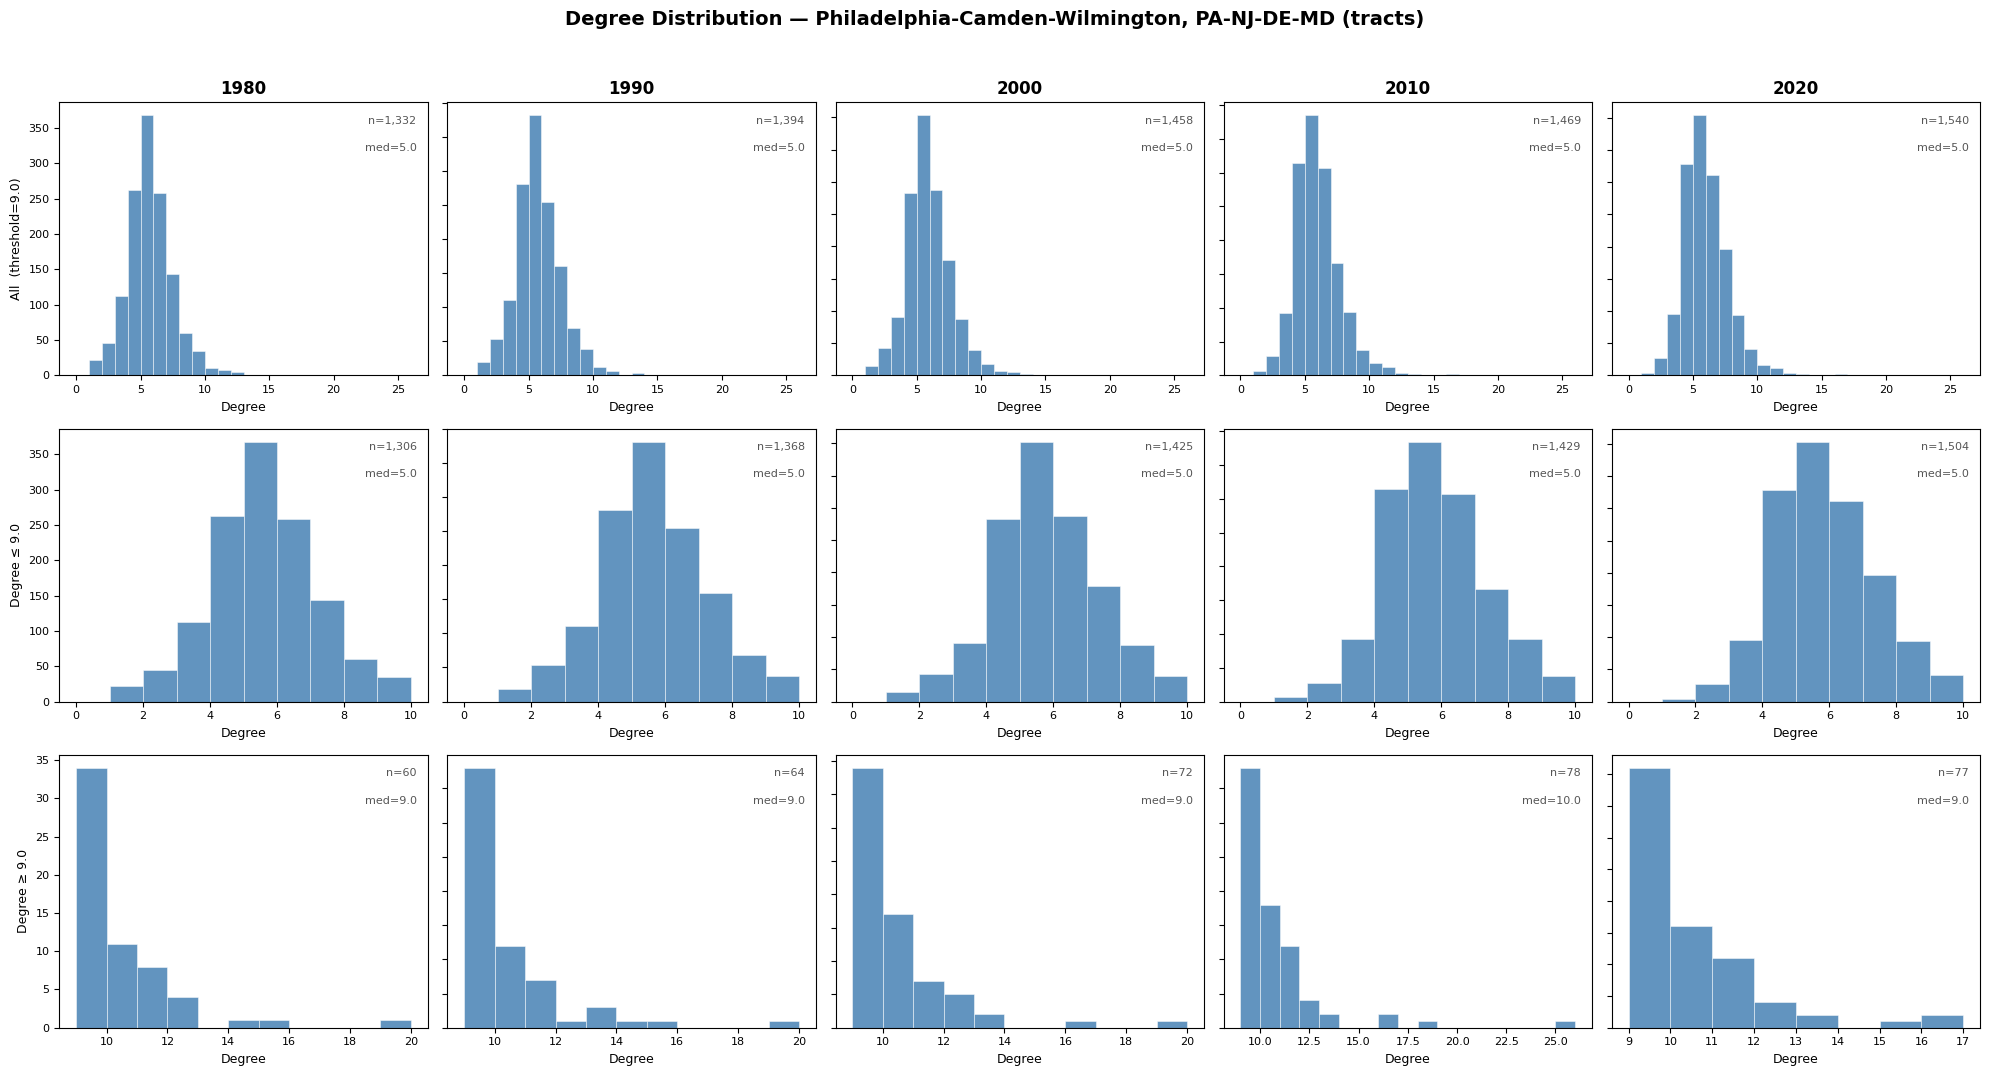

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_tracts_degree_report.txt

Degree statistics — Philadelphia-Camden-Wilmington, PA-NJ-DE-MD (tracts)  (threshold = 9.0)
  Year   Leaves      Mean    Median    Min    Max       Std
------------------------------------------------------------
  1980       22      5.24      5.00      1     19      1.83
  1990       19      5.26      5.00      1     19      1.84
  2000       14      5.42      5.00      1     19      1.81
  2010        6      5.49      5.00      1     25      1.86
  2020        4      5.49      5.00      1     16      1.75
Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_block_groups_degree_dist.png


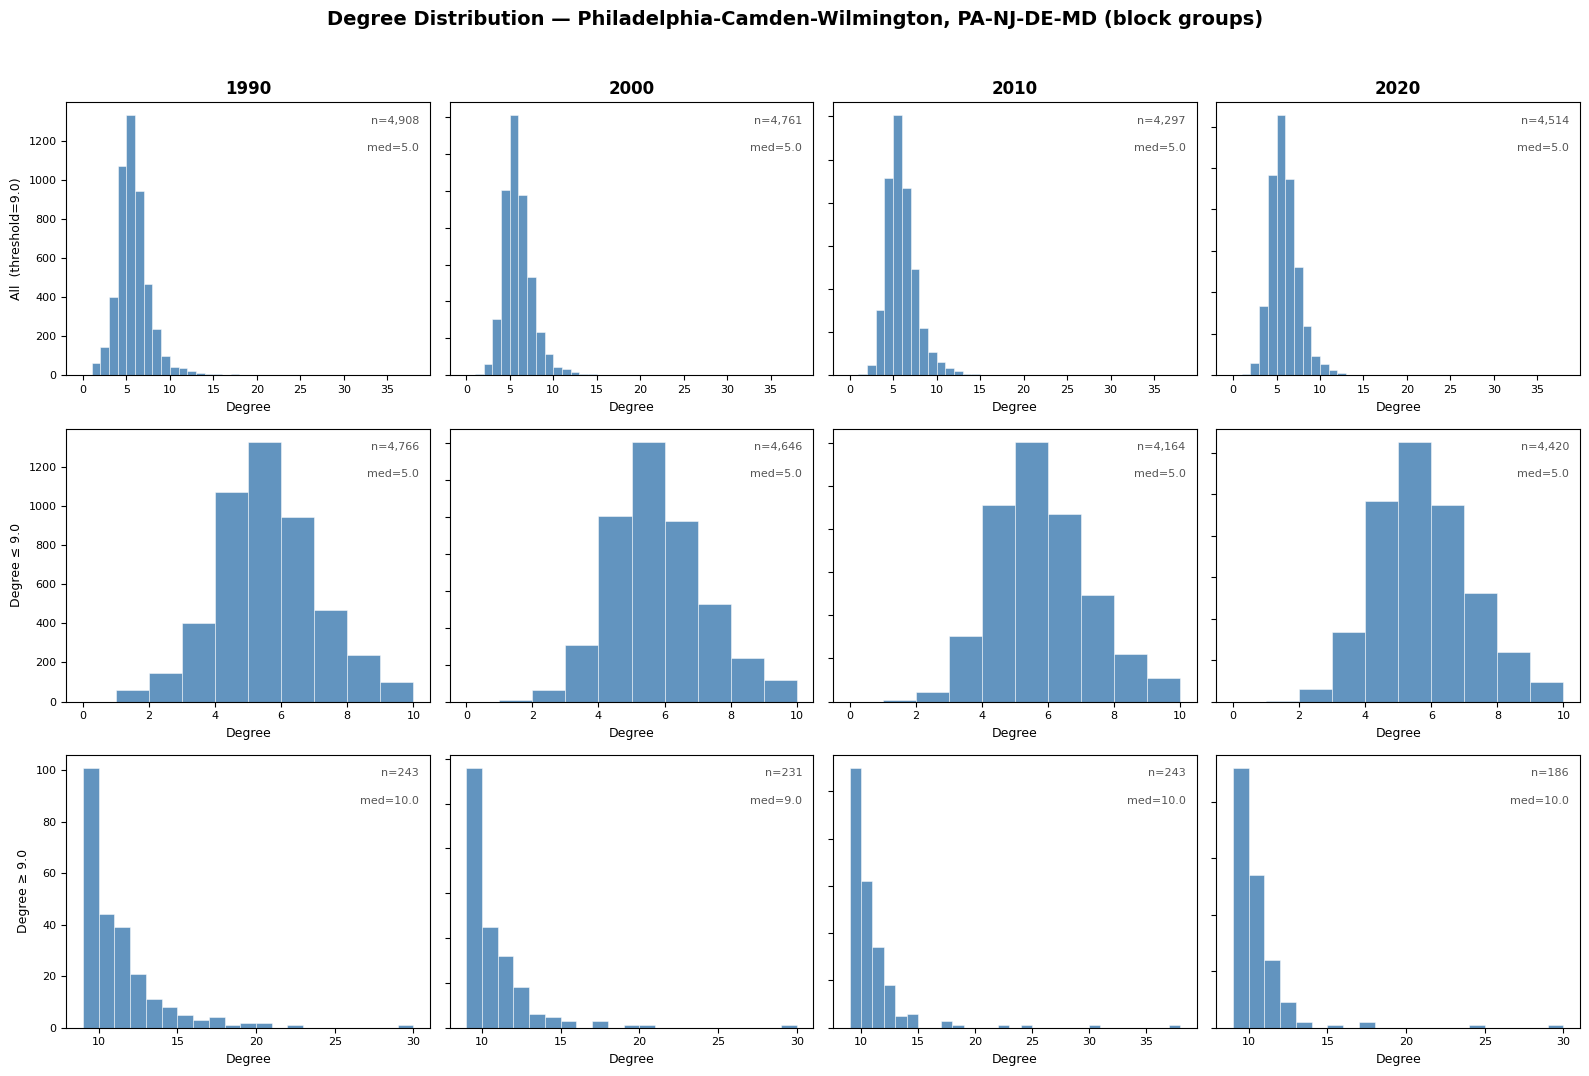

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_block_groups_degree_report.txt

Degree statistics — Philadelphia-Camden-Wilmington, PA-NJ-DE-MD (block groups)  (threshold = 9.0)
  Year   Leaves      Mean    Median    Min    Max       Std
------------------------------------------------------------
  1990       61      5.30      5.00      1     29      1.98
  2000        7      5.45      5.00      1     29      1.76
  2010        5      5.50      5.00      1     37      1.90
  2020        4      5.40      5.00      1     29      1.69


In [47]:
plot_degree_distribution_maup(CBSA)

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_1980_black_share_above_threshold_maup_graph.png


/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_15238/3187108826.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


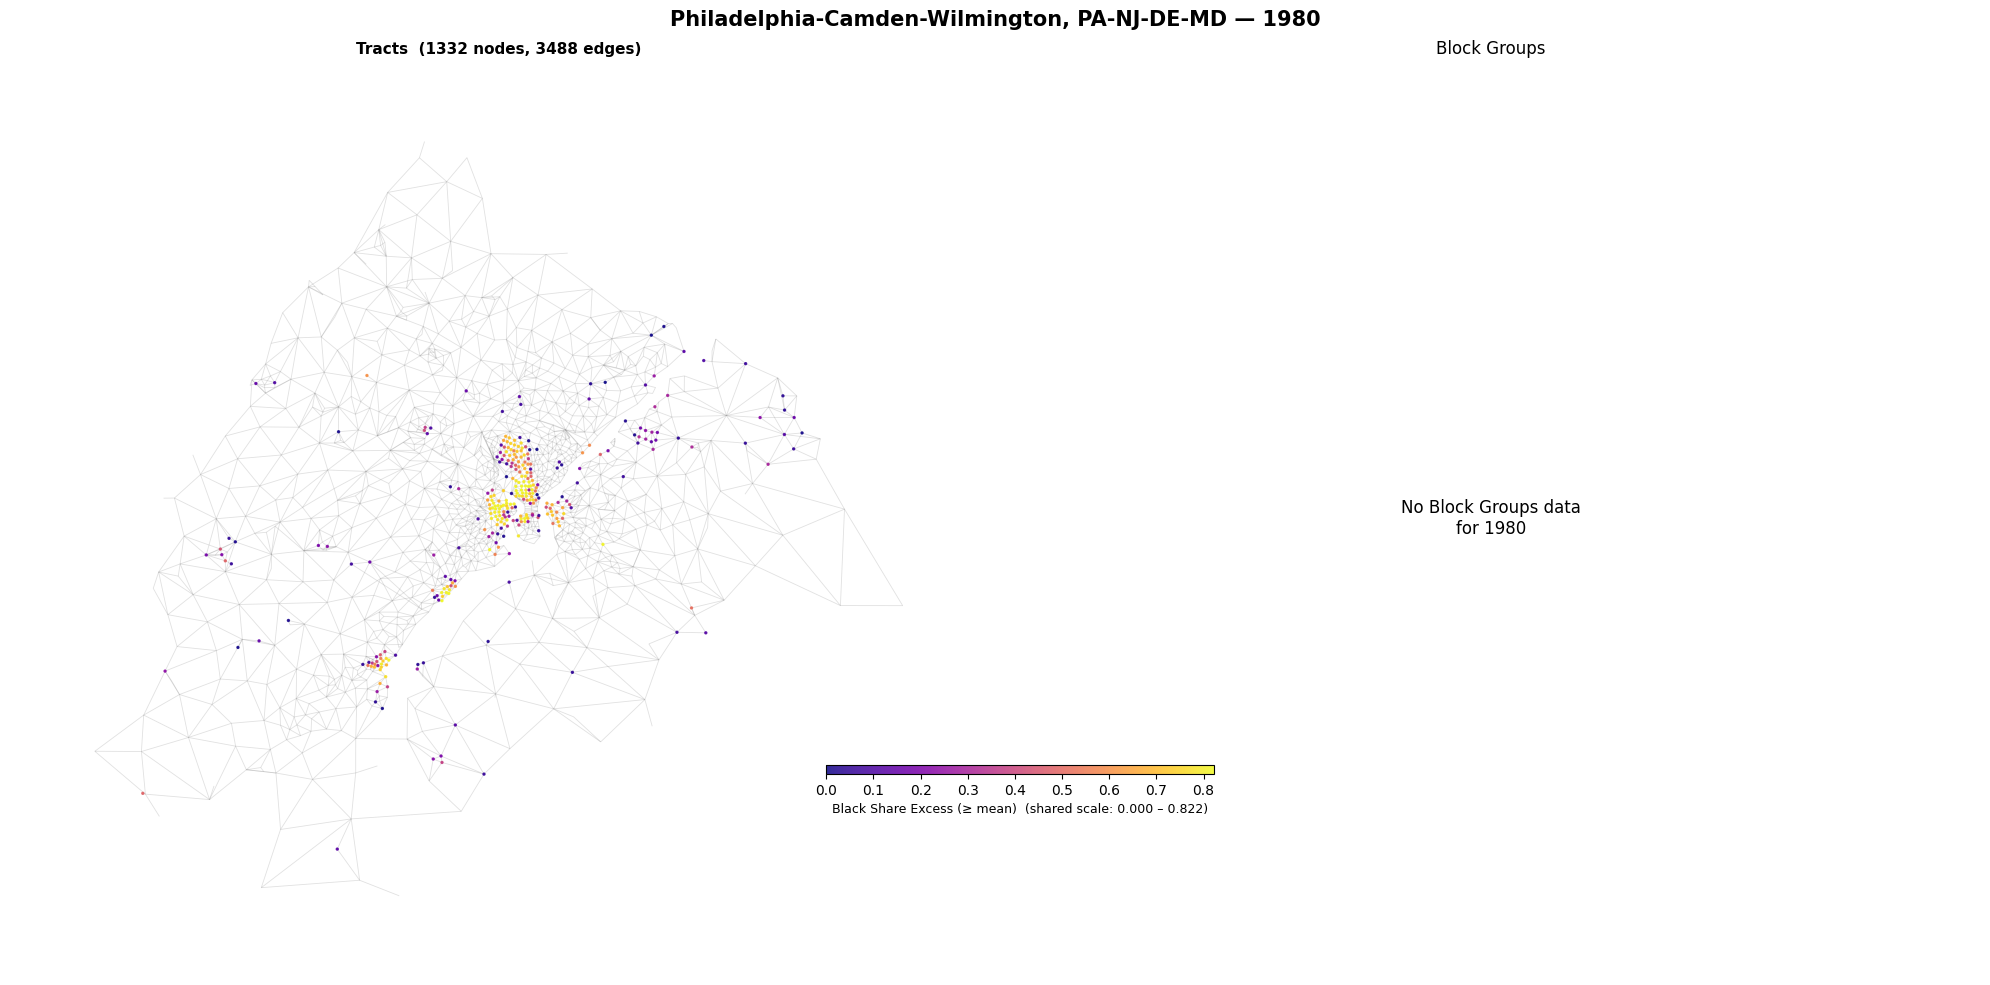

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_1990_black_share_above_threshold_maup_graph.png


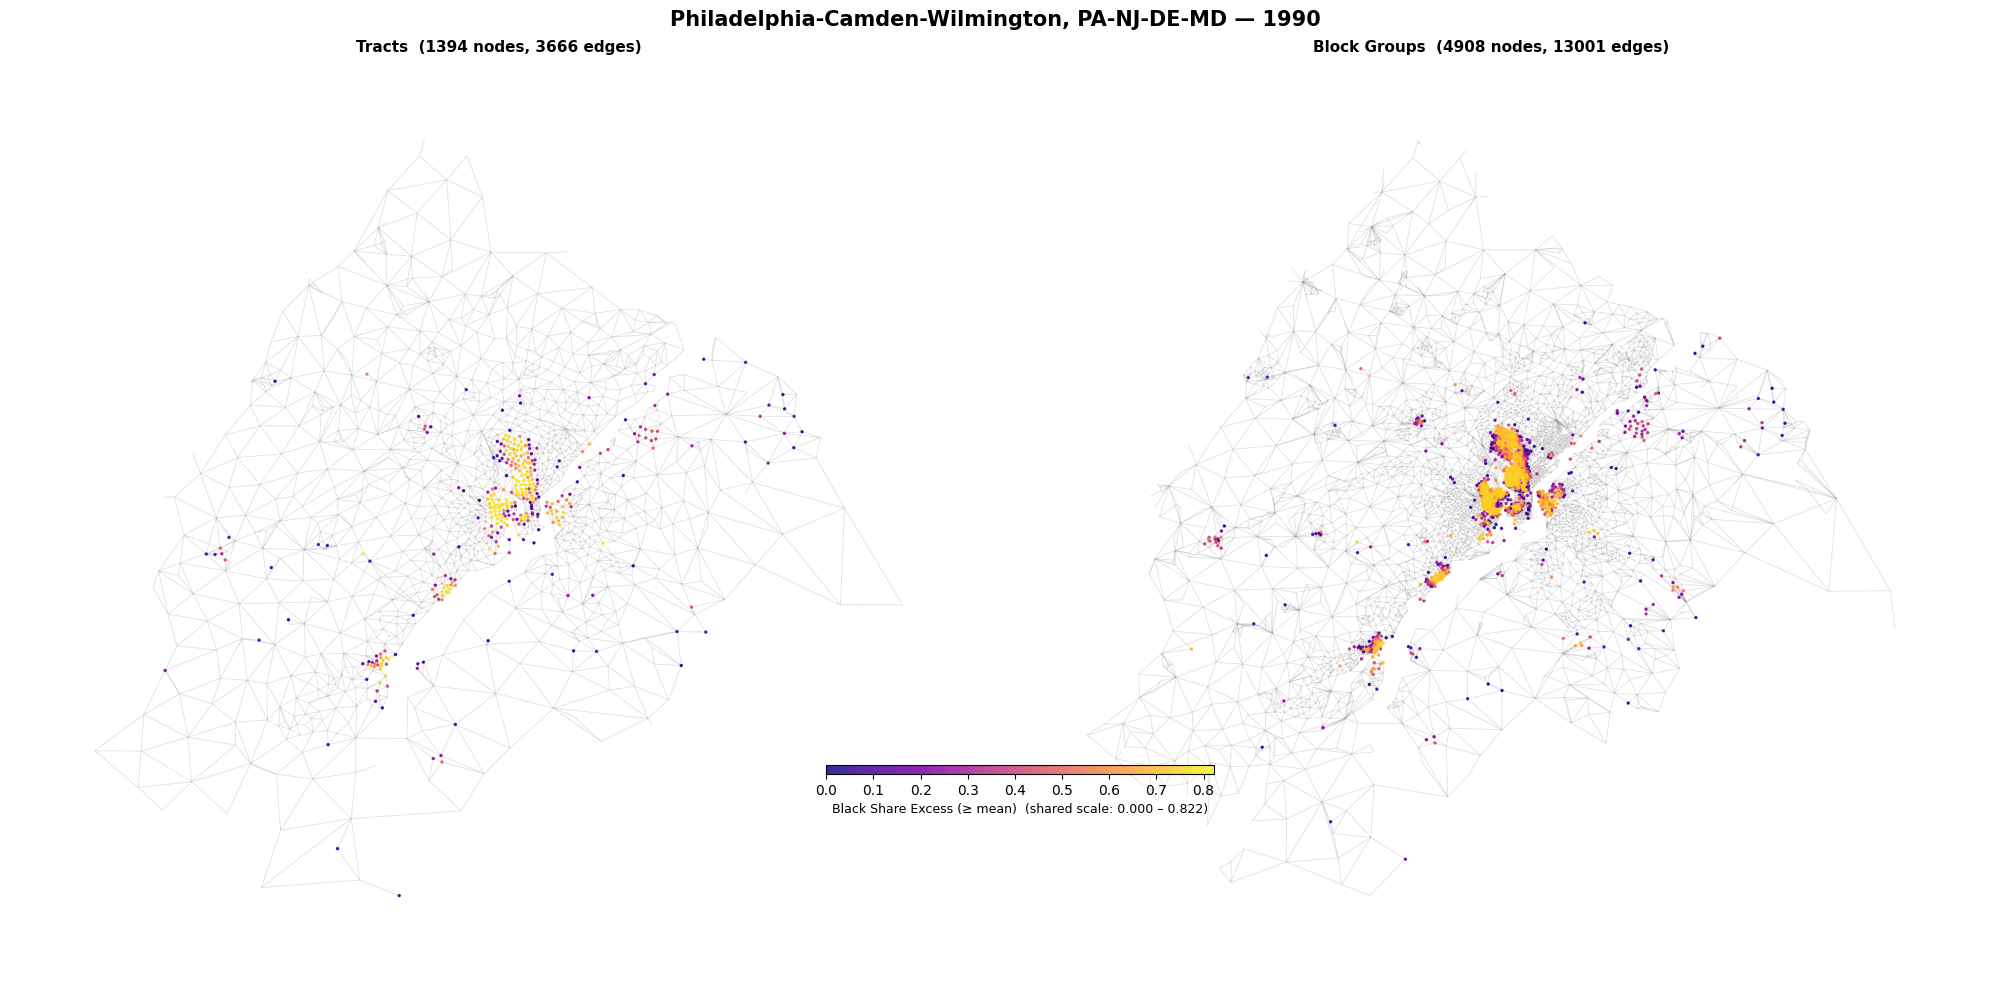

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_2000_black_share_above_threshold_maup_graph.png


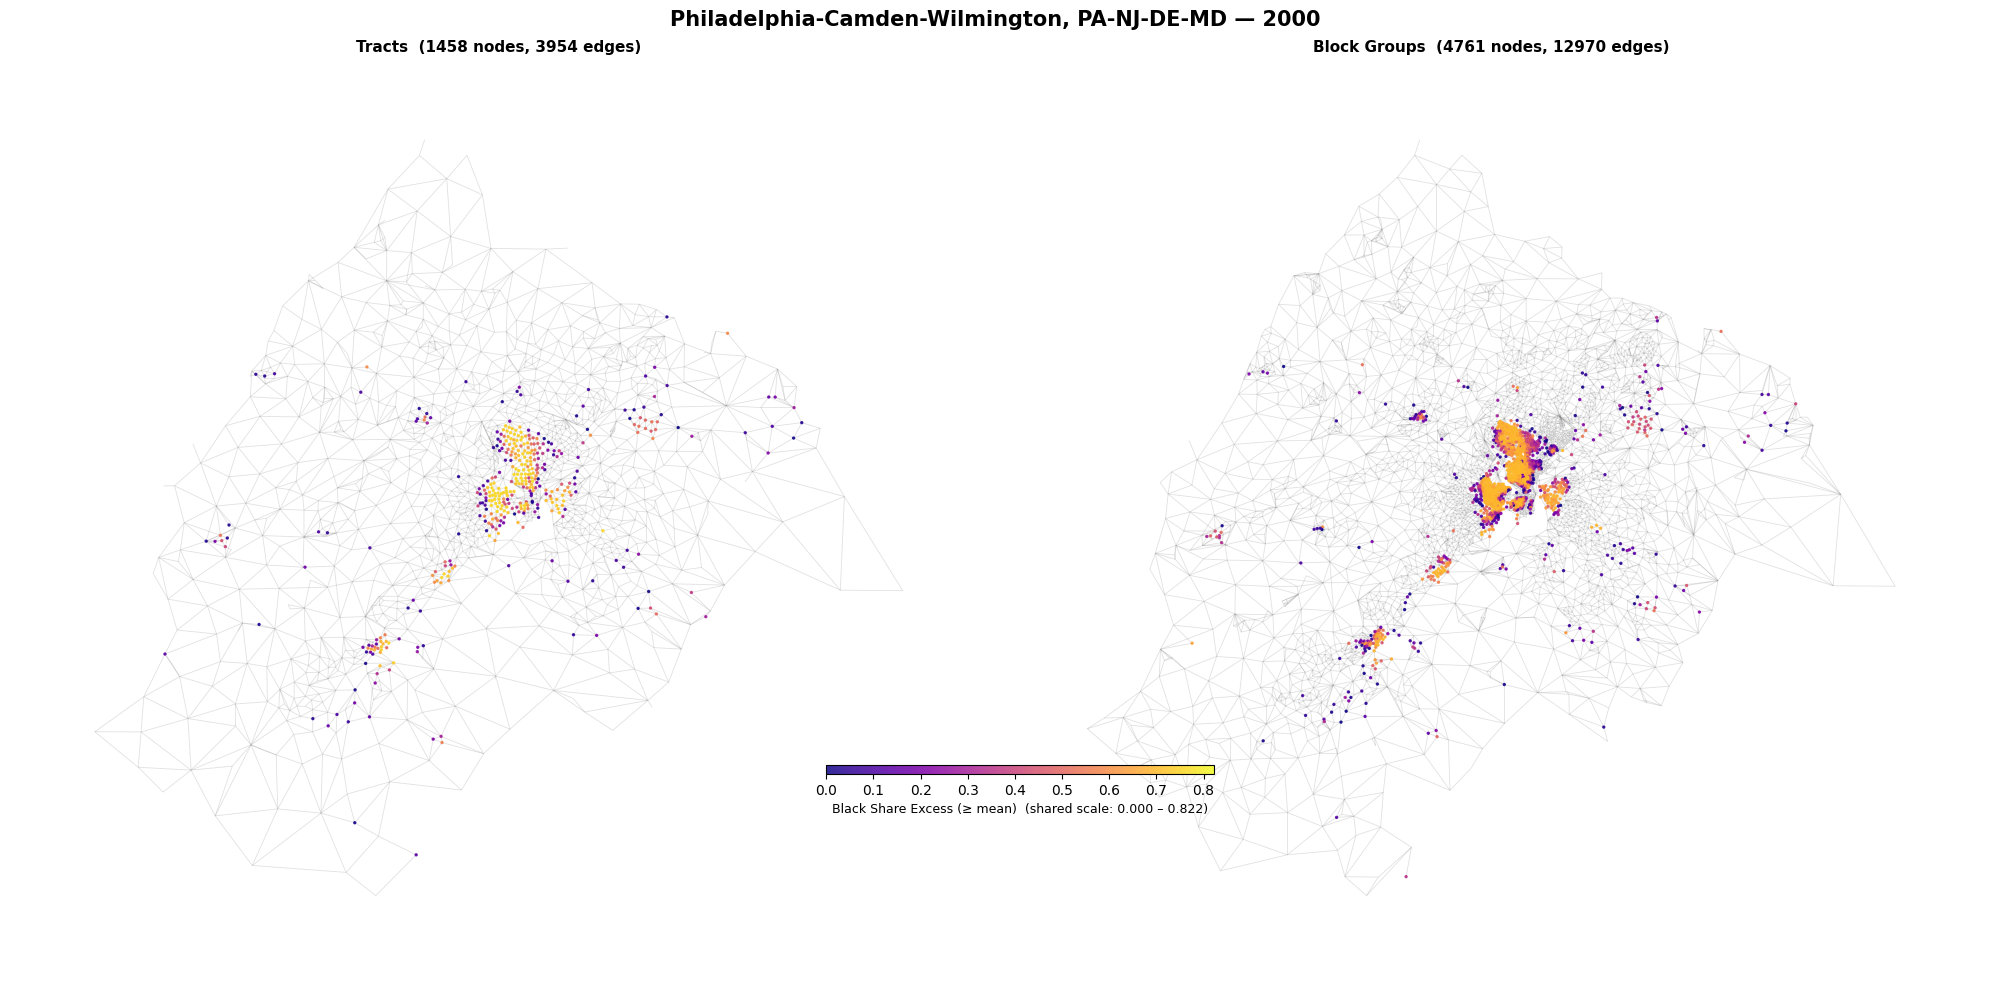

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_2010_black_share_above_threshold_maup_graph.png


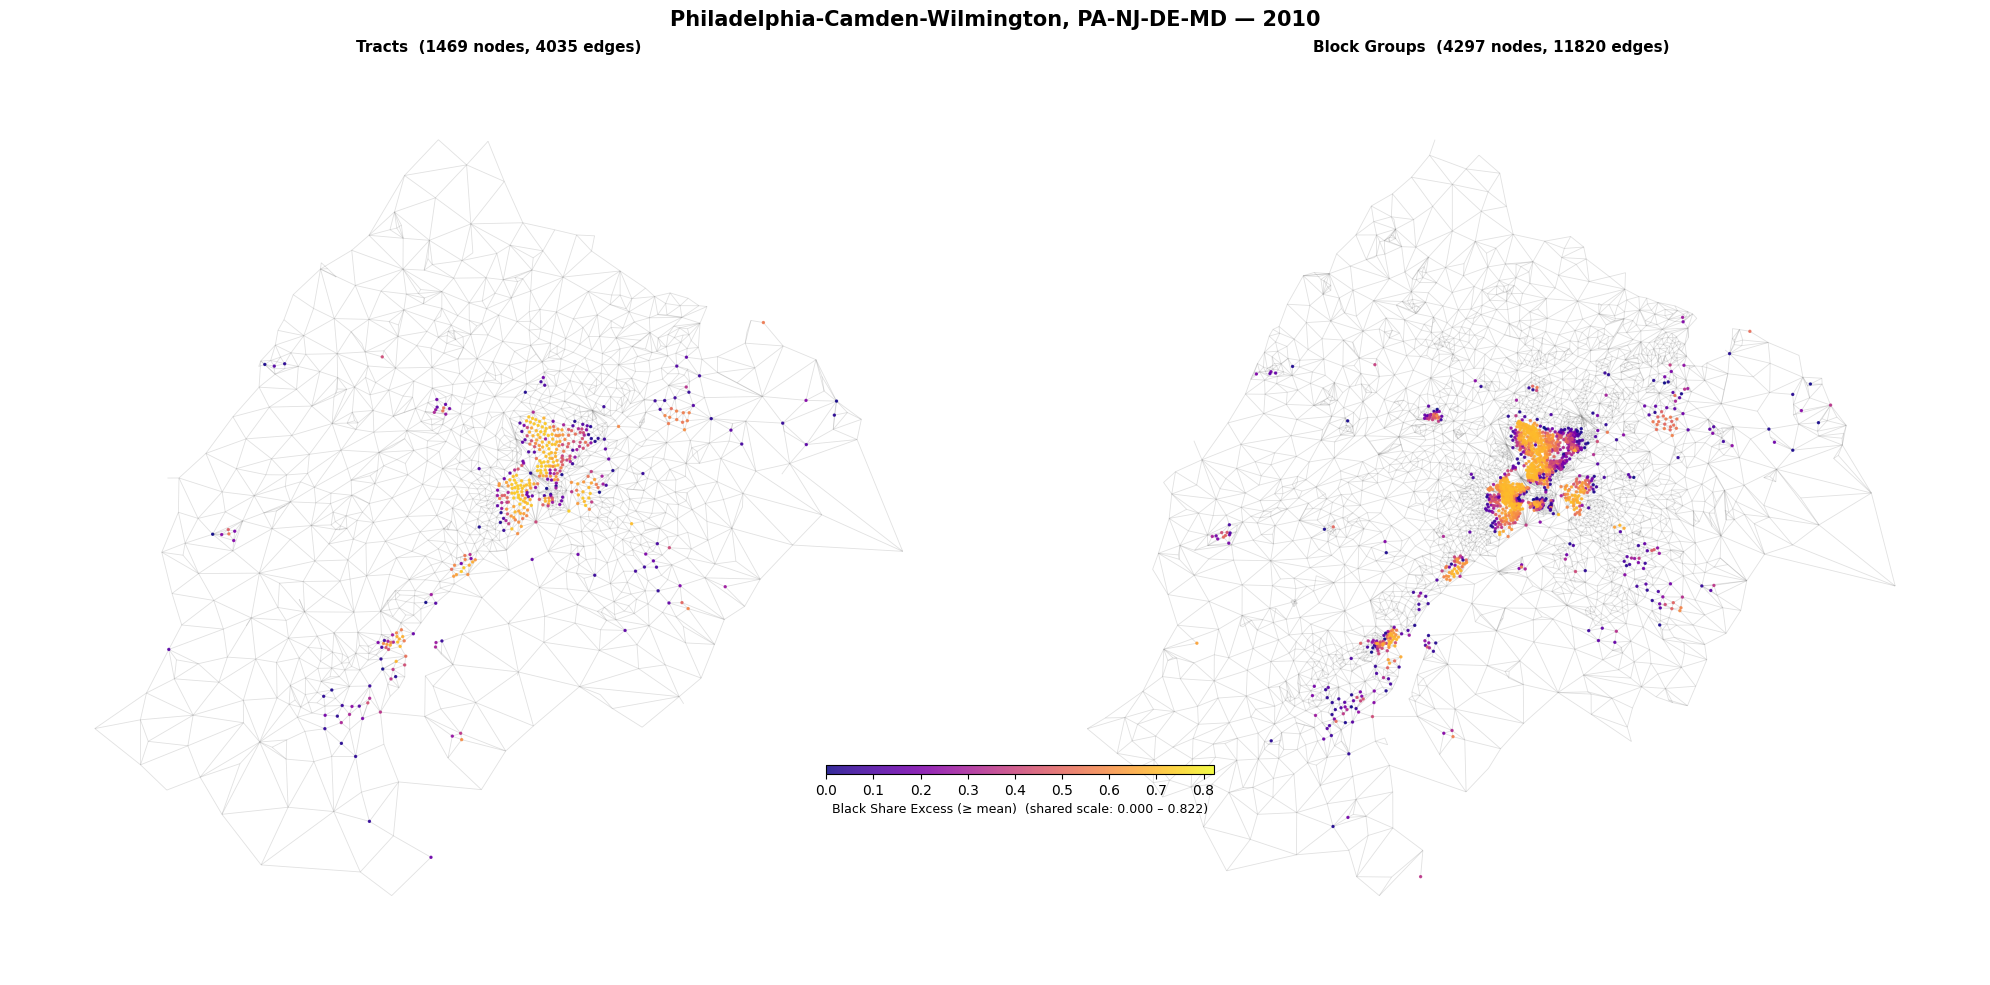

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_2020_black_share_above_threshold_maup_graph.png


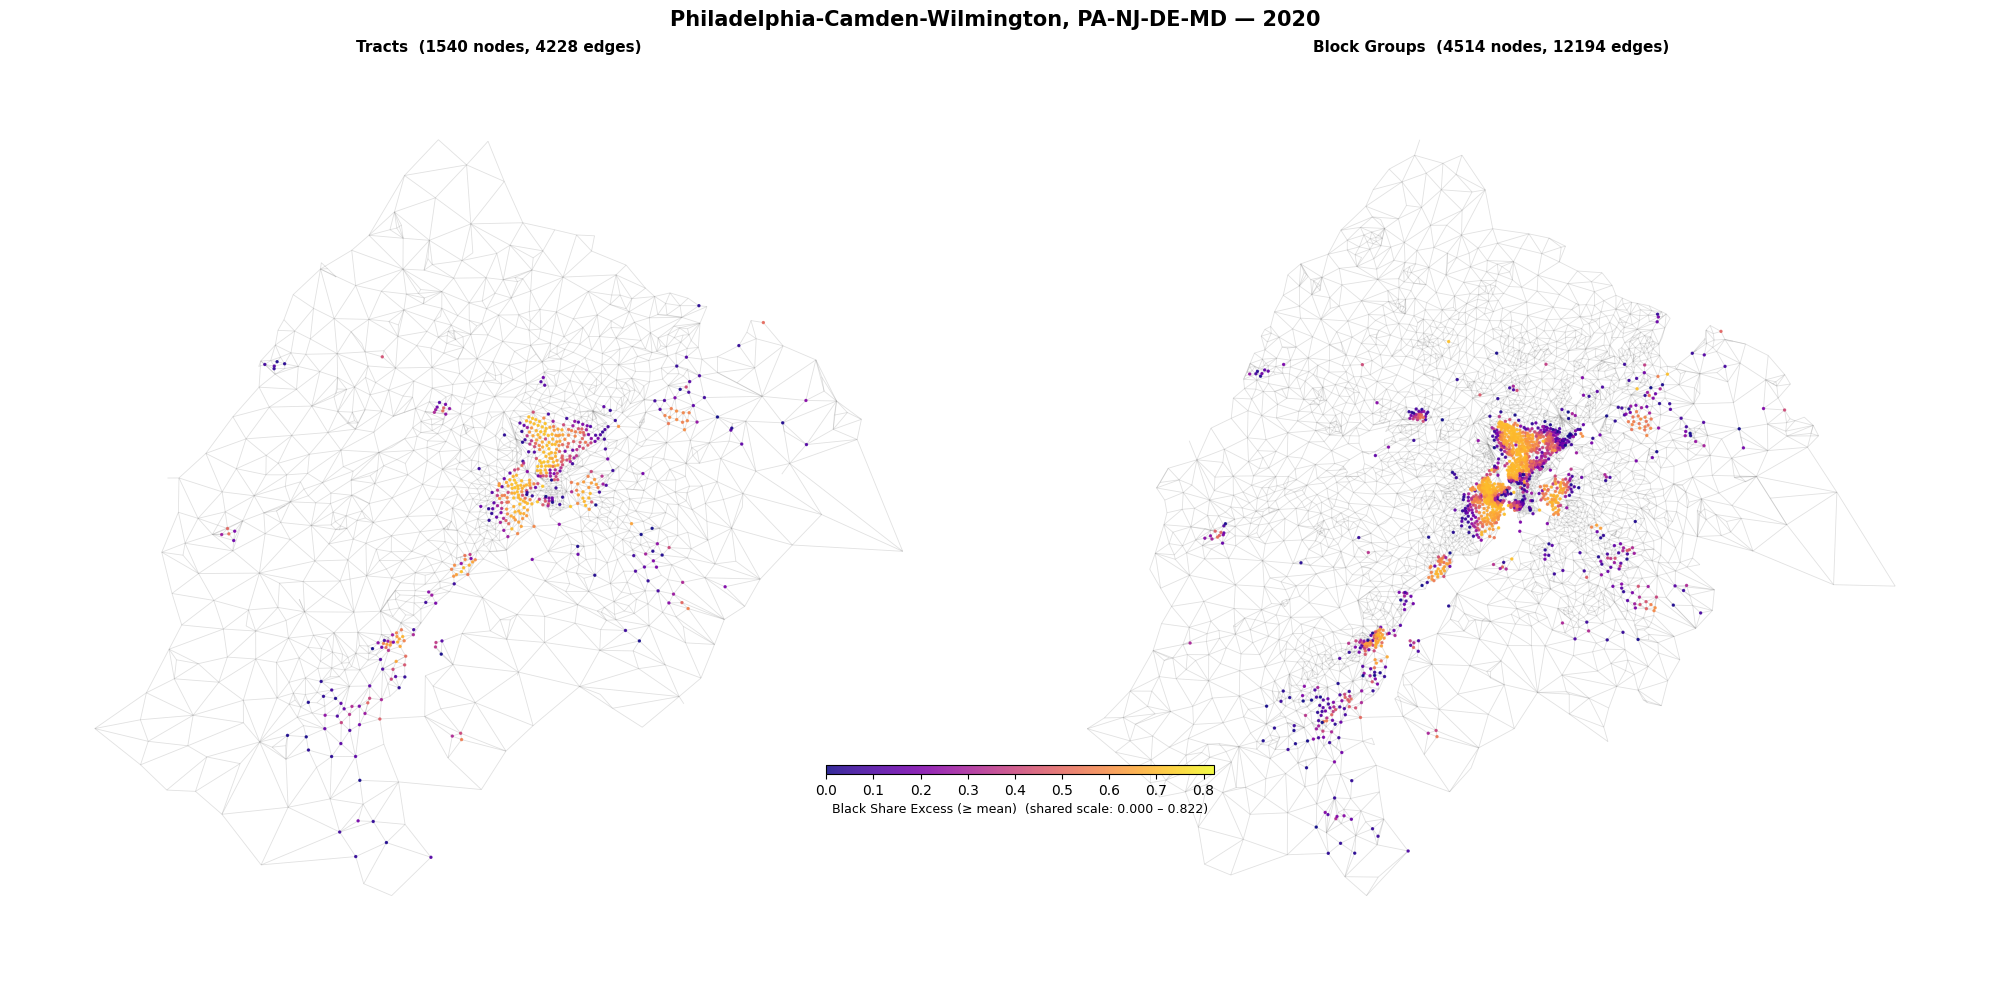

Graph report — Philadelphia-Camden-Wilmington, PA-NJ-DE-MD

── Tracts ──

Graph Structure
  Year   Nodes   Edges
----------------------
  1980    1332    3488
  1990    1394    3666
  2000    1458    3954
  2010    1469    4035
  2020    1540    4228

Black Share  (BLACK / (BLACK + WHITE))
  Year        Mean      Median         Min         Max         Std
---------------------------------------------------------------
  1980      0.1783      0.0276      0.0000      1.0000      0.2964
  1990      0.1980      0.0394      0.0000      0.9987      0.3066
  2000      0.2327      0.0647      0.0000      0.9971      0.3183
  2010      0.2611      0.0923      0.0000      1.0000      0.3239
  2020      0.2749      0.1141      0.0000      1.0000      0.3168

POC Share  (POC / TOTPOP)
  Year        Mean      Median         Min         Max         Std
---------------------------------------------------------------
  1980      0.2032      0.0545      0.0000      1.0000      0.2968
  1990      0.2338

In [48]:
plot_graph_maup(CBSA, var='black_share_above_threshold', threshold='mean')

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_maup_scores.png


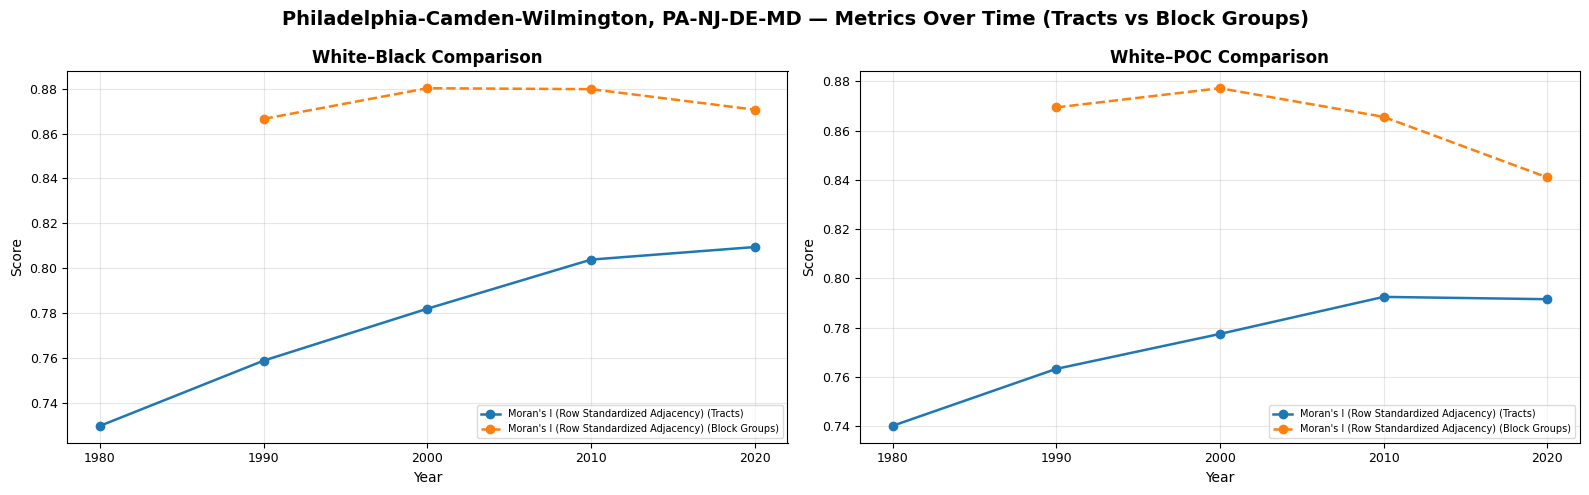

In [49]:
metrics = ["moran_P"]

plot_score_graph_maup(CBSA, metrics)

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_maup_graph_stats.png


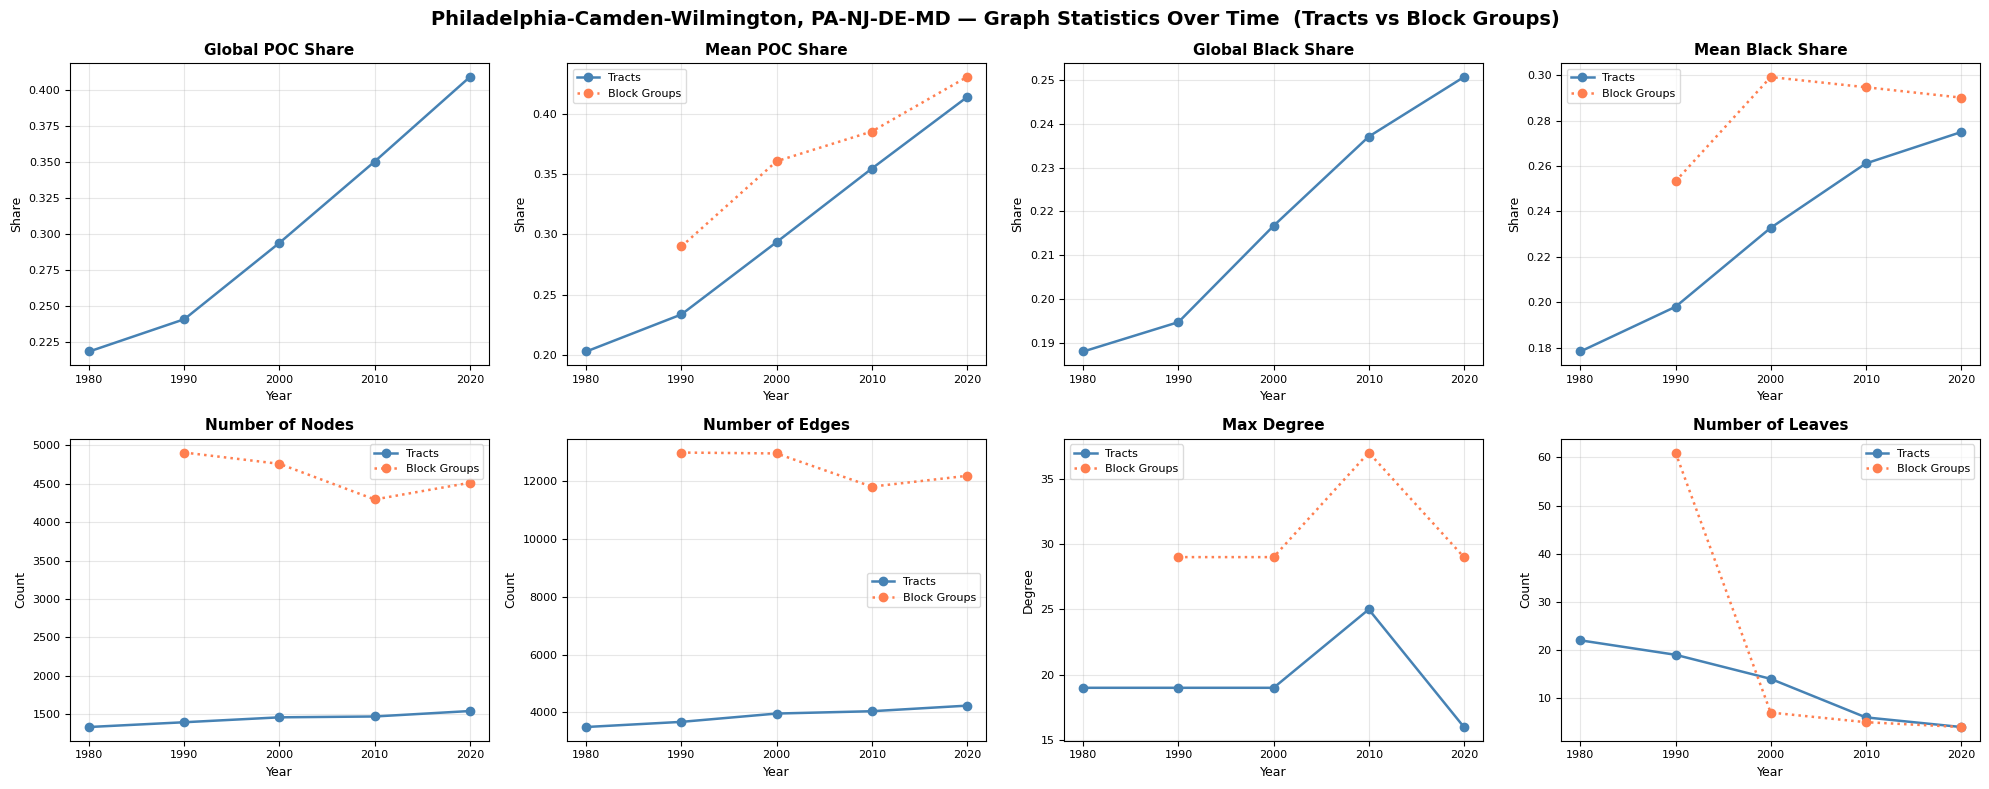

In [50]:
plot_graph_stats_maup(CBSA)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_15238/1375260805.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_black_avg_maup_threshold.png


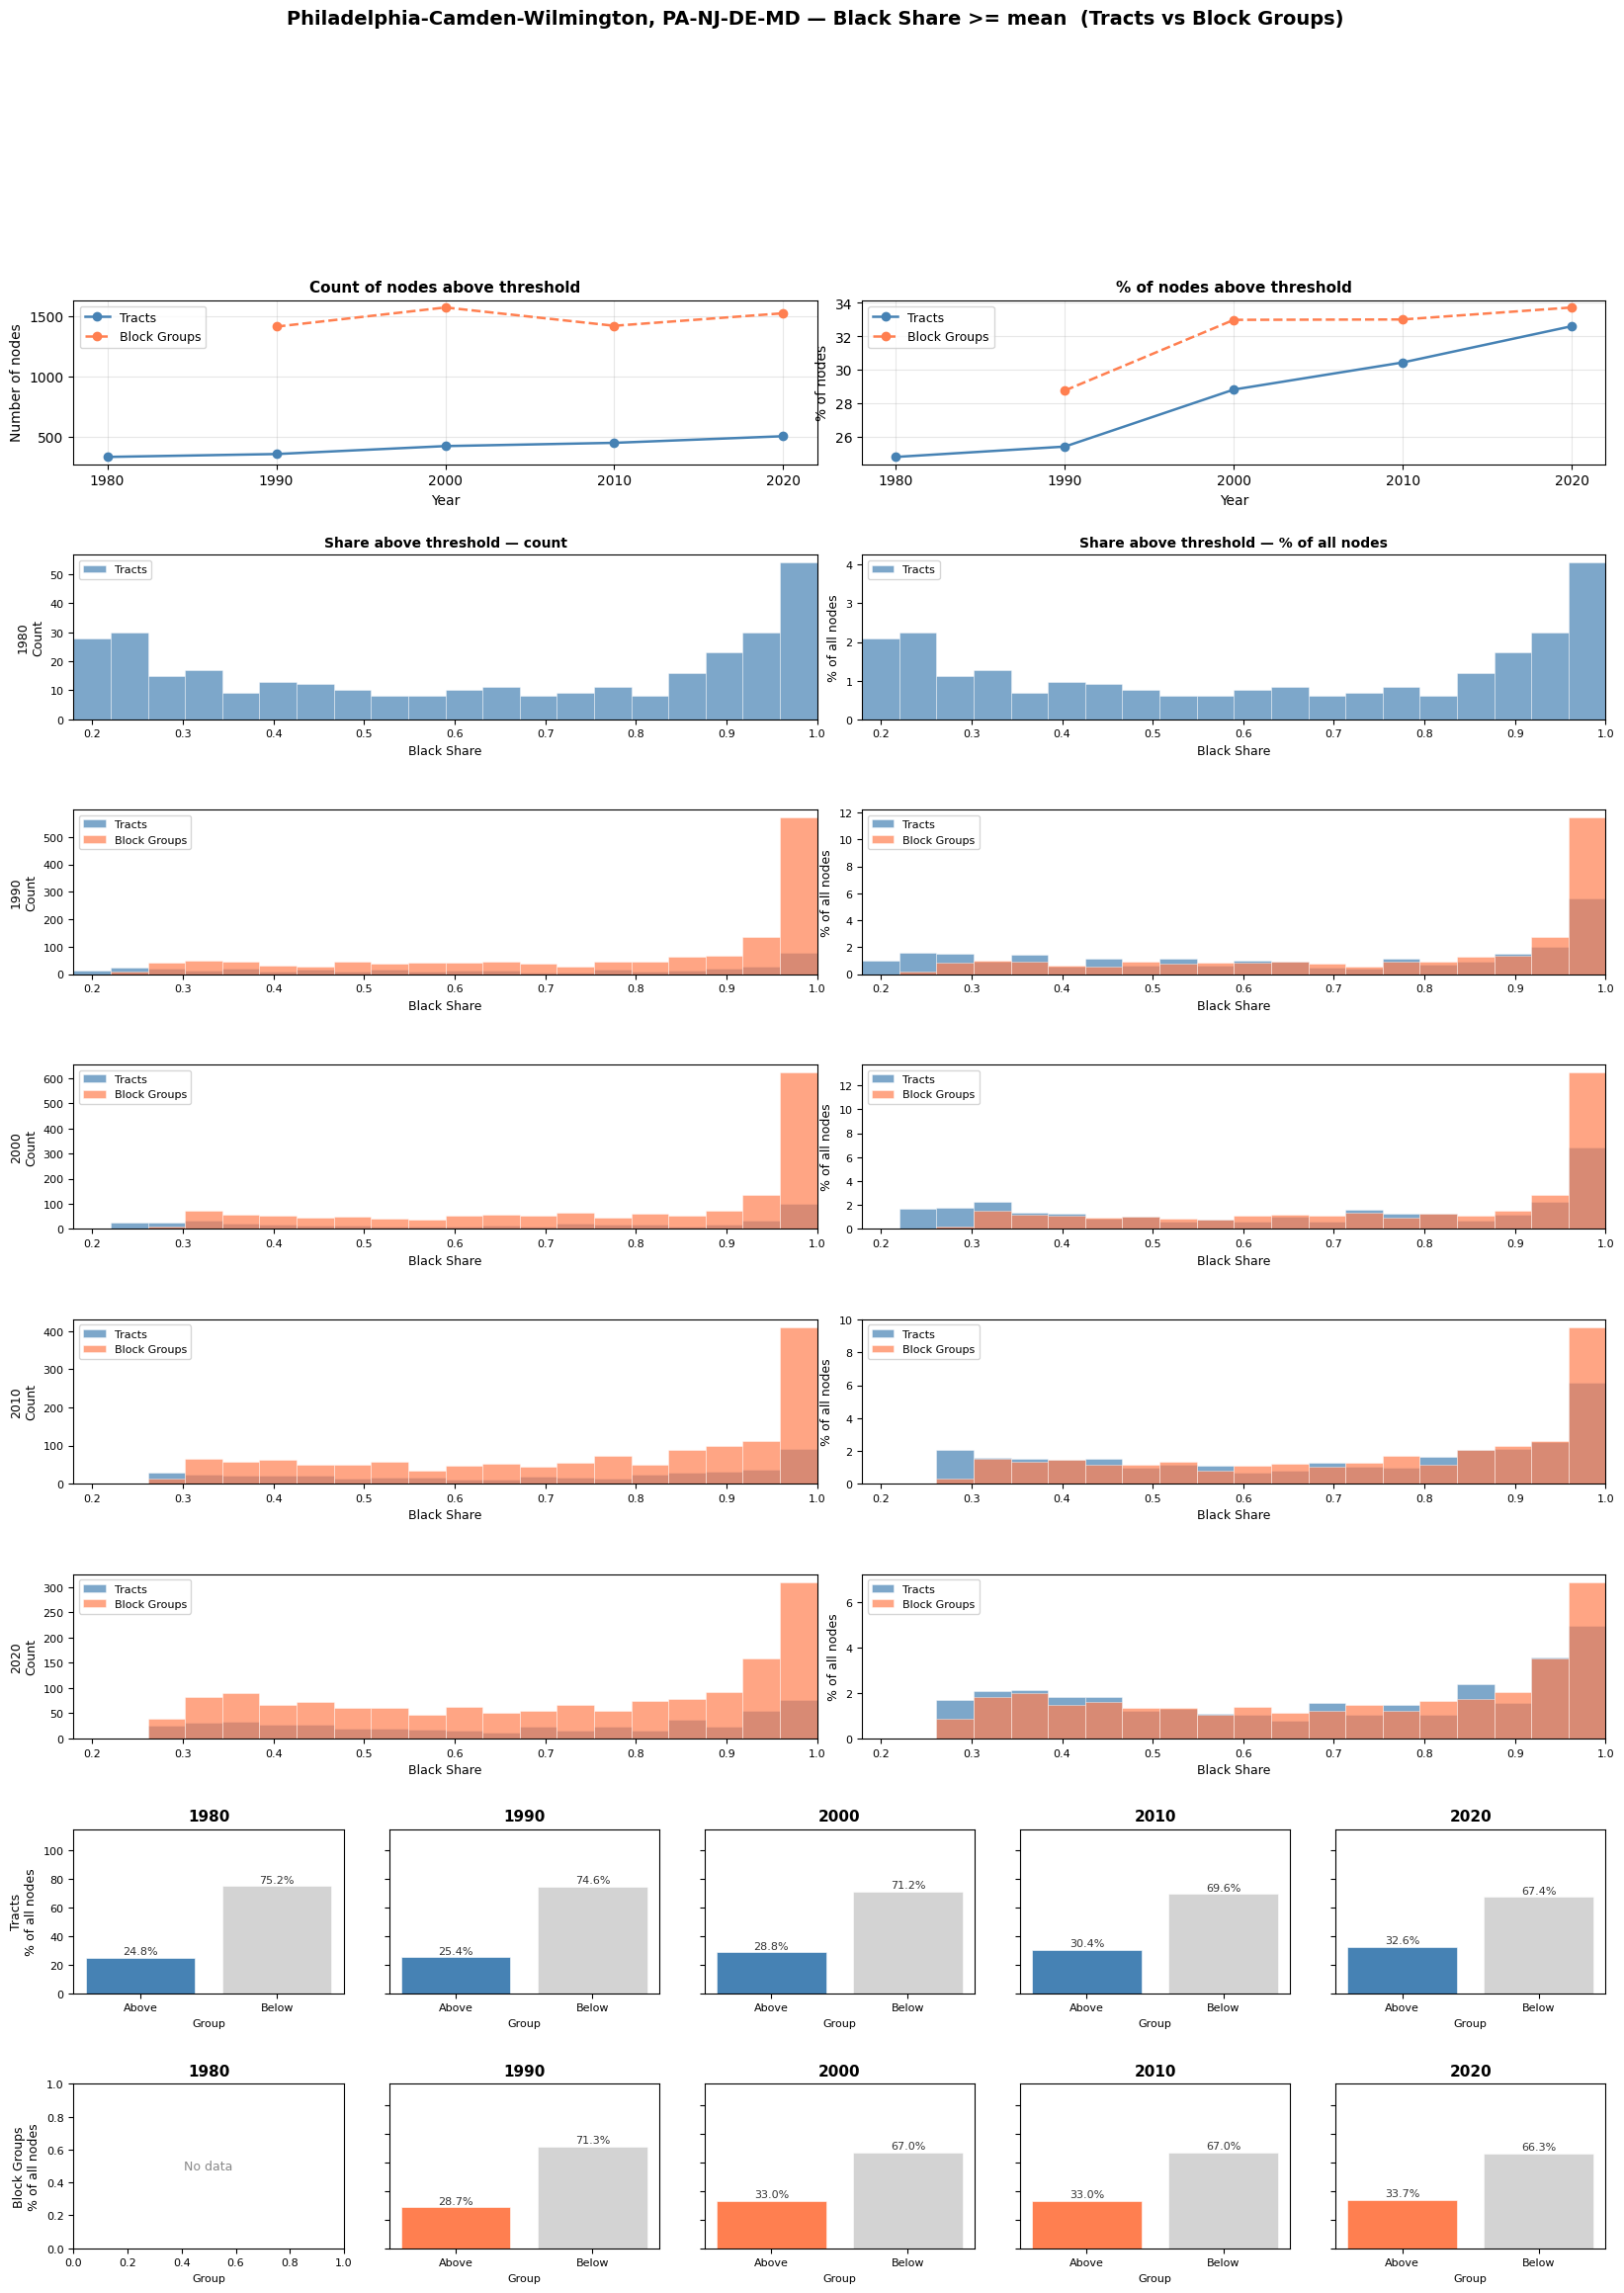

Philadelphia-Camden-Wilmington, PA-NJ-DE-MD — Black Share threshold report (>= mean)

── Tracts ──
  Year   Total   Above       Pct      Cutoff
--------------------------------------------
  1980    1332     330    24.77%      0.1783
  1990    1394     354    25.39%      0.1980
  2000    1458     420    28.81%      0.2327
  2010    1469     447    30.43%      0.2611
  2020    1540     502    32.60%      0.2749

── Block Groups ──
  Year   Total   Above       Pct      Cutoff
--------------------------------------------
  1990    4908    1411    28.75%      0.2532
  2000    4761    1570    32.98%      0.2991
  2010    4297    1418    33.00%      0.2947
  2020    4514    1522    33.72%      0.2901
Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_black_avg_maup_threshold_report.txt


In [51]:
plot_threshold_counts_maup(CBSA, comparison='black', threshold='avg')
# plot_threshold_counts_maup(CBSA, comparison='poc', threshold='avg')

Saved Figures/MAUP Figures/Philadelphia_maup/cbsa_37980_black_avg_maup_components.png


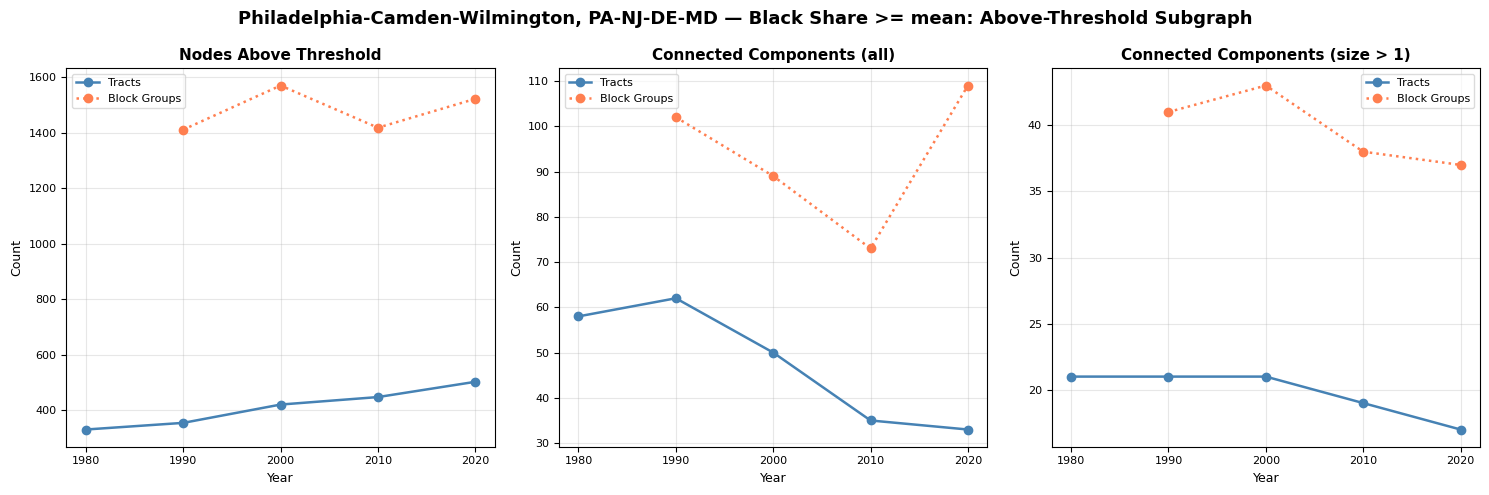


Philadelphia-Camden-Wilmington, PA-NJ-DE-MD — Black Share >= mean: Connected Components

Tracts
    Year   N Above   All Comp   Comp >1
  ------------------------------------
    1980       330         58        21
    1990       354         62        21
    2000       420         50        21
    2010       447         35        19
    2020       502         33        17

Block Groups
    Year   N Above   All Comp   Comp >1
  ------------------------------------
    1990      1411        102        41
    2000      1570         89        43
    2010      1418         73        38
    2020      1522        109        37


In [52]:
plot_threshold_components_maup(CBSA, comparison='black', threshold='avg')